In [4]:
!nvidia-smi

Fri Mar 20 11:32:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [12]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [1]:
!pip install yfinance

In [2]:
import yfinance as yf                  # downloads market data from Yahoo Finance
import pandas as pd                    # table/dataframe manipulation
import numpy as np                     # numerical arrays and math
import matplotlib.pyplot as plt        # plotting
from scipy.stats import norm, linregress   # normal cdf/pdf and linear regression
from math import sqrt                  #square root function

In [4]:
!pip install arch

In [5]:
from arch import arch_model            # GARCH model

In [6]:
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "ADBE", "CRM", "ORCL",
    "JPM", "BAC", "GS", "MS", "WFC",
    "C", "BLK", "AXP", "SCHW", "USB",
    "JNJ", "PFE", "MRK", "LLY", "ABBV",
    "TMO", "UNH", "CVS", "AMGN", "GILD",
    "KO", "PEP", "WMT", "COST", "HD",
    "MCD", "NKE", "SBUX", "TGT", "DIS",
    "XOM", "CVX", "COP", "SLB", "EOG",
    "BA", "CAT", "GE", "HON", "UPS",
    "SPY", "QQQ", "IWM", "DIA", "VTI"]

index_tickers = [
    "^GSPC", "^DJI", "^IXIC", "^NDX",
    "^RUT","^VIX", "^NYA", "^FTSE", "^GDAXI",
    "^FCHI", "^N225", "^HSI", "^STOXX50E", "^BSESN",
    "^AXJO", "^MXX", "^BVSP", "^KS11", "^TWII", "^GSPTSE" ]
stock_data = yf.download(tickers, start='2018-01-01', end='2025-01-01', auto_adjust=True, progress=False)

In [7]:
stock_data = stock_data[['Close']].dropna()

In [8]:
stock_data=stock_data.rename(columns={'Close': 'S'})
stock_returns = 1+ stock_data.pct_change()

stock_returns.iloc[0] = 1

stock_log_returns = np.log(stock_returns)
stock_log_returns.head()
stock_log_returns['S']['AAPL'].head()


,AAPL
Date,
2018-01-02,0.000000
2018-01-03,-0.000174
2018-01-04,0.004634
2018-01-05,0.011321
2018-01-08,-0.003721


In [90]:
def bs_price_delta(S, K, r, sigma, tau, option_type="call", q=0.0):

    "Compute Black-Scholes price and delta for a European call or put."

    if tau <= 0:
        # if time to maturity is zero or negative, then option is already at maturity

        if option_type == "call":
            price = max(S - K, 0.0)
            # intrinsic value of call at maturity

            delta = 1.0 if S > K else 0.0
            # approximate maturity delta for call

        else:
            price = max(K - S, 0.0)
            # intrinsic value of put at maturity

            delta = -1.0 if S < K else 0.0
            # approximate maturity delta for put

        return price, delta
        # return payoff and maturity delta

    d1 = (np.log(S/K) + (r-q + 0.5*sigma**2) * tau)/(sigma*np.sqrt(tau))
    # Black-Scholes d1 formula, q is dividend

    d2 = d1 - sigma * np.sqrt(tau)
    # Black-Scholes d2 formula

    if option_type == "call":
        price = S * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
        # call price formula under dividend yield q

        delta = np.exp(-q * tau) * norm.cdf(d1)
        # call delta formula

    else:
        price = K * np.exp(-r * tau) * norm.cdf(-d2) - S * np.exp(-q * tau) * norm.cdf(-d1)
        # put price formula

        delta = -np.exp(-q * tau) * norm.cdf(-d1)
        # put delta formula

    return float(price), float(delta)
    # return price and delta as plain Python floats


In [91]:
bs_price_delta(S=250, K=300, r=0.05, sigma=0.2, tau=5/252, option_type="call", q=0.0)

(7.003206076154475e-11, 6.703919839951913e-11)

In [92]:
def garch_vol_forecast(log_returns, horizon_days=21): #return_model= False):
    "Fit GARCH(1,1) to daily log returns and forecast average annualized volatility over horizon_days."

    returns_pct = 100 * log_returns.dropna()
    # arch package usually works better when returns are expressed in percent

    archm = arch_model(returns_pct, vol='Garch', p=1, q=1, mean='Constant', dist='normal')
    # define GARCH(1,1):
    # variance_t = omega + alpha * eps_{t-1}^2 + beta * variance_{t-1}

    res = archm.fit(disp="off")
    # fit the GARCH model without printing iteration output

    fore_cast = res.forecast(horizon=horizon_days, reindex=False)
    # forecast future conditional variances for the next horizon_days

    var_forecasts = fore_cast.variance.values[-1] / (100**2)
    # take the latest forecast row
    # divide by 100^2 because returns were scaled to percent

    avg_daily_var = np.mean(var_forecasts)
    # average future daily variance across forecast horizon

    annualized_vol = np.sqrt(252 * avg_daily_var)
    # annualize daily variance to annual volatility
    return float(annualized_vol), res
    #if return_model:
        #return float(annualized_vol), res
    #else:
        #return float(annualized_vol)
    # return annualized volatility forecast


In [93]:
 garch_vol_forecast(stock_log_returns['S']['META'], horizon_days=21)

(0.45185240258936377,
                      Constant Mean - GARCH Model Results                      
 Dep. Variable:                   META   R-squared:                       0.000
 Mean Model:             Constant Mean   Adj. R-squared:                  0.000
 Vol Model:                      GARCH   Log-Likelihood:               -4155.62
 Distribution:                  Normal   AIC:                           8319.24
 Method:            Maximum Likelihood   BIC:                           8341.13
                                         No. Observations:                 1761
 Date:                Fri, Mar 20 2026   Df Residuals:                     1760
 Time:                        16:53:25   Df Model:                            1
                                Mean Model                               
                  coef    std err          t      P>|t|  95.0% Conf. Int.
 ------------------------------------------------------------------------
 mu             0.0155      0.110   

In [94]:
def estimate_cev_params(stock_data, dt=1/252):
    "Estimate CEV parameters delta and beta from historical prices using the log-linear approximation:log((dS)^2/dt) = log(delta^2) + 2*beta*log(S) + noise"

    S = stock_data.values
    # convert pandas series to numpy array

    dS = np.diff(S)
    # price increments S_t - S_{t-1}

    x = np.log(S[:-1] + 1e-12)
    # explanatory variable = log(S_t) add tiny constant for numerical stability

    y = np.log((dS**2) / dt + 1e-18)
    # dependent variable = log((dS)^2 / dt) add tiny constant for numerical stability

    slope, intercept, _, _, _ = linregress(x, y)
    # run linear regression y = intercept + slope * x

    beta = slope / 2.0
    # since slope = 2*beta

    delta = np.exp(intercept / 2.0)
    # since intercept = log(delta^2)
    beta = float(np.clip(beta, 0.3, 1.3)) #bound the beta to make sure the simulations later remain stable
    delta = float(np.clip(delta, 1e-4, 5.0))
    return float(delta), float(beta)
    # return estimated CEV parameters

In [95]:
estimate_cev_params(stock_data['S']['META'], dt=1/252)

(0.9625905812539985, 0.6655618531896311)

In [96]:
def cev_mc_price(S_0, K, r, q, delta, beta, tau, option_type="call",n_steps=100, n_sims=4000, seed=42):

    "Price of an European option under the CEV model by Monte Carlo."

    np.random.seed(seed)
    # set random seed so results are reproducible

    if tau <= 0:
        # if already at maturity, return payoff directly
        return max(S_0 - K, 0.0) if option_type == "call" else max(K - S_0, 0.0)

    dt = tau / n_steps
    # time step size for Euler simulation
    beta = float(np.clip(beta, 0.3, 1.3))
    delta = float(np.clip(delta, 1e-4, 5.0))
    S = np.full(n_sims, S_0, dtype=float)
    # create n_sims simulated paths, all starting at S0

    for _ in range(n_steps):
        # iterate path evolution over time steps

        Z = np.random.normal(size=n_sims)
        # generate standard normal shocks for all paths

        S_safe = np.clip(S, 1e-8, 1e6)
        diffusion = delta * np.power(S_safe, beta) * np.sqrt(dt) * Z
        diffusion = np.clip(diffusion, -1e6, 1e6)
        S = S + (r - q) * S_safe * dt + diffusion
        S = np.clip(np.where(np.isfinite(S), S, 1e-8), 1e-8, 1e6)
        #S = S + (r - q) * S * dt + delta * np.power(np.maximum(S, 1e-8), beta) * np.sqrt(dt) * Z
        # Euler discretization of the CEV SDE: dS = (r-q)S dt + delta * S^beta dW

        S = np.maximum(S, 1e-8)
        # prevent negative or zero prices numerically

    if option_type == "call":
        payoff = np.maximum(S - K, 0.0)
        # call payoff for each simulated terminal price
    else:
        payoff = np.maximum(K - S, 0.0)
        # put payoff

    return float(np.exp(-r * tau) * np.mean(payoff))
    # discount average payoff back to time 0

In [97]:
cev_mc_price(S_0=250, K=200, r=0.05, q=0, delta=0.9625905812539985, beta=0.6655618531896311 , tau=2, option_type="call",n_steps=80, n_sims=4000, seed=42)

70.14909985713902

In [98]:
def cev_delta(S_0, K, r, q, delta, beta, tau, option_type="call",bump_pct=0.01, n_steps=100, n_sims=3000):
    "Approximate delta under CEV by finite difference:delta ≈ [V(S+h)-V(S-h)] / (2h)"

    h = bump_pct * S_0
    # choose shock size as 1% of spot

    p_up = cev_mc_price(S_0 + h, K, r, q, delta, beta, tau,
                      option_type=option_type, n_steps=n_steps, n_sims=n_sims, seed=1)
    # price with bumped-up spot

    p_down = cev_mc_price(S_0 - h, K, r, q, delta, beta, tau,
                      option_type=option_type, n_steps=n_steps, n_sims=n_sims, seed=1)
    # price with bumped-down spot

    return (p_up - p_down) / (2 * h)
    # central finite-difference delta estimate

In [99]:
def hedge_backtest(stock_path, model_name="bs", option_type="call", moneyness=1.0, maturity_days=21, r=0.03, q=0.0,lookback=252, fixed_sigma=0.20):
    """
    Backtest daily delta hedging on rolling windows.

    For each start date:
    - estimate model parameters from previous lookback window
    - price 1 European option
    - compute delta
    - rebalance daily
    - compute terminal hedging error
    """

    S = stock_path.dropna()
    dates = S.index
    results = []

    for start_idx in range(lookback, len(S) - maturity_days - 1):

        # windows
        hist_window = S.iloc[start_idx - lookback:start_idx]
        trade_window = S.iloc[start_idx:start_idx + maturity_days + 1]

        # initial values
        S_0 = float(np.asarray(trade_window.iloc[0]).item())
        K = moneyness * S_0
        tau_0 = maturity_days / 252

        # MODEL-DEPENDENT INITIAL PRICE AND DELTA
        if model_name == "bs":
            V_0, delta_0 = bs_price_delta(S_0, K, r, fixed_sigma, tau_0, option_type, q=q)

        elif model_name == "garch":
            vol_forecast, _ = garch_vol_forecast(
                np.log(hist_window / hist_window.shift(1)).dropna(),
                horizon_days=maturity_days
            )
            V_0, delta_0 = bs_price_delta(S_0, K, r, vol_forecast, tau_0, option_type, q=q)

        elif model_name == "cev":
            delta_cev, beta_cev = estimate_cev_params(hist_window)

            V_0 = cev_mc_price(
                S_0, K, r, q, delta_cev, beta_cev, tau_0,
                option_type=option_type, n_steps=100, n_sims=4000, seed=123
            )

            delta_0 = cev_delta(
                S_0, K, r, q, delta_cev, beta_cev, tau_0,
                option_type=option_type, bump_pct=0.01,
                n_steps=100, n_sims=100
            )

        else:
            raise ValueError("Unknown model")

        #initial hedge
        cash = V_0 - delta_0 * S_0
        prev_delta = delta_0

        # DAILY REBALANCING
        for j in range(1, maturity_days):

            S_j = float(np.asarray(trade_window.iloc[j]).item())
            tau_j = (maturity_days - j) / 252

            if model_name == "bs":
                _, new_delta = bs_price_delta(S_j, K, r, fixed_sigma, tau_j, option_type, q=q)

            elif model_name == "garch":
                hist_until_j = S.iloc[start_idx - lookback + j:start_idx + j]

                vol_forecast, _ = garch_vol_forecast(
                    np.log(hist_until_j / hist_until_j.shift(1)).dropna(),
                    horizon_days=max(maturity_days - j, 1)
                )

                _, new_delta = bs_price_delta(S_j, K, r, vol_forecast, tau_j, option_type, q=q)

            elif model_name == "cev":
                hist_until_j = S.iloc[start_idx - lookback + j:start_idx + j]

                delta_cev, beta_cev = estimate_cev_params(hist_until_j)

                new_delta = cev_delta(
                    S_j, K, r, q, delta_cev, beta_cev, tau_j,
                    option_type=option_type, bump_pct=0.01,
                    n_steps=100, n_sims=100
                )

            # cash update (self-financing)
            cash = cash * np.exp(r / 252) - (new_delta - prev_delta) * S_j
            prev_delta = new_delta

        #  MATURITY
        S_T = float(np.asarray(trade_window.iloc[maturity_days]).item())

        cash = cash * np.exp(r / 252)
        final_portfolio = prev_delta * S_T + cash

        payoff = max(S_T - K, 0.0) if option_type == "call" else max(K - S_T, 0.0)

        hedge_error = final_portfolio - payoff

        results.append({
            "start_date": dates[start_idx],
            "S_0": S_0,
            "K": K,
            "S_T": S_T,
            "model": model_name,
            "initial_price": V_0,
            "hedge_error": hedge_error,
            "abs_hedge_error": abs(hedge_error)
        })

    return pd.DataFrame(results)

In [100]:
meta_bs_hedge_backtest=hedge_backtest(stock_data['S']['META'], model_name="bs", option_type="call", moneyness=1.0, maturity_days=21, r=0.03, q=0.0,lookback=252, fixed_sigma=0.20)

In [52]:
meta_bs_hedge_backtest.to_pickle("meta_bs_hedge_backtest.pkl")

In [53]:
meta_garch_hedge_backtest=hedge_backtest(stock_data['S']['META'], model_name="garch", option_type="call",moneyness=1.0, maturity_days=21, r=0.03, q=0.0,lookback=252, fixed_sigma=0.20)

In [54]:
meta_garch_hedge_backtest.to_pickle("meta_garch_hedge_backtest.pkl")

In [55]:
meta_cev_hedge_backtest=hedge_backtest(stock_data['S']['META'], model_name="cev", option_type="call",moneyness=1.0, maturity_days=21, r=0.03, q=0.0,lookback=252, fixed_sigma=0.20)

In [56]:
meta_cev_hedge_backtest.to_pickle("meta_cev_hedge_backtest.pkl")

In [101]:
def run_ticker_study(stock_data,ticker,start="2018-01-01",end="2025-01-01",option_type="call",moneyness=1.0,maturity_days=21,r=0.03,q=0.0,lookback=252,fixed_sigma=0.20):

    "Run the full backtest for multiple tickers and all models."


    all_results = []
    # collect results across both tickers
        # loop through ticker symbols one by one

    price_series = stock_data['S'][ticker]
    if isinstance(price_series, pd.DataFrame):
      price_series = price_series.iloc[:, 0]
    price_series = pd.Series(price_series).dropna().astype(float)
        # download daily price data
    #for ticker in tickers:
    for model in ["bs", "garch", "cev"]:
      res = hedge_backtest(
                stock_path=price_series,
                model_name=model,
                option_type=option_type,
                moneyness=moneyness,
                maturity_days=maturity_days,
                r=r,
                q=q,
                lookback=lookback,
                fixed_sigma=fixed_sigma
            )
            # perform rolling hedging experiment

      res["ticker"] = ticker
            # add ticker label to each row

      all_results.append(res)
            # store results

    return pd.concat(all_results, ignore_index=True)
    # combine everything into one dataframe

In [57]:
meta_study=run_ticker_study(stock_data,ticker='META',start="2018-01-01",end="2025-01-01",option_type="call",moneyness=1.0,maturity_days=21,r=0.03,q=0.0,lookback=252,fixed_sigma=0.20)

In [58]:
meta_study.to_pickle("meta_study.pkl")

In [59]:
from google.colab import files
files.download("meta_bs_hedge_backtest.pkl")
files.download("meta_garch_hedge_backtest.pkl")
files.download("meta_cev_hedge_backtest.pkl")
files.download("meta_study.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
from google.colab import files
uploaded = files.upload()

Saving meta_bs_hedge_backtest.pkl to meta_bs_hedge_backtest (1).pkl
Saving meta_cev_hedge_backtest.pkl to meta_cev_hedge_backtest (1).pkl
Saving meta_garch_hedge_backtest.pkl to meta_garch_hedge_backtest (1).pkl
Saving meta_study.pkl to meta_study (1).pkl


In [102]:
def summarize_ticker_results(results):

    "Summarize hedge performance by model for one ticker."

    summary = results.groupby("model").agg(
        mean_error=("hedge_error", "mean"),
        median_error=("hedge_error", "median"),
        std_error=("hedge_error", "std"),
        mae=("abs_hedge_error", "mean"),
        rmse=("hedge_error", lambda x: np.sqrt(np.mean(np.array(x) ** 2))),
        worst_loss=("hedge_error", "min"),
        best_gain=("hedge_error", "max"),
        n_obs=("hedge_error", "count")
    ).reset_index()

    return summary

In [61]:
meta_study = pd.read_pickle("meta_study.pkl")

meta_summary = summarize_ticker_results(meta_study)

In [62]:
meta_summary.head()

,model,mean_error,median_error,std_error,mae,rmse,worst_loss,best_gain,n_obs
0,bs,-5.237058,-3.328605,6.843103,5.296459,8.615297,-60.850656,2.435961,1487
1,cev,-7.760020,-5.177728,9.047614,7.803202,11.917306,-75.604623,2.812850,1487
2,garch,2.248248,2.607861,8.050284,5.324906,8.355723,-55.811104,38.536061,1487


In [125]:
latex_table_string = meta_summary.to_latex(index=False, float_format="{:.6f}".format)
file_name = 'meta_table.tex'

# Save the string to a .tex file
with open(file_name, 'w') as f:
    f.write(latex_table_string)

print(f"DataFrame converted and saved to {file_name}")

DataFrame converted and saved to meta_table.tex


In [126]:
from google.colab import files
files.download("meta_table.tex")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [114]:
from google.colab import files
uploaded = files.upload()

Saving aapl_study.pkl to aapl_study.pkl


In [127]:
aapl_study=pd.read_pickle("aapl_study.pkl")
aapl_summary=summarize_ticker_results(aapl_study)
latex_table_string = aapl_summary.to_latex(index=False, float_format="{:.6f}".format)
file_name = 'aapl_table.tex'

# Save the string to a .tex file
with open(file_name, 'w') as f:
    f.write(latex_table_string)

print(f"DataFrame converted and saved to {file_name}")


DataFrame converted and saved to aapl_table.tex


In [124]:
aapl_summary

,model,mean_error,median_error,std_error,mae,rmse,worst_loss,best_gain,n_obs
0,bs,-1.023956,-0.617856,1.795684,1.290700,2.066591,-12.940214,2.649652,1487
1,cev,-2.126167,-1.354209,2.520760,2.192815,3.297051,-19.765502,1.064381,1487
2,garch,0.203152,0.368283,1.670636,1.231579,1.682385,-8.222914,6.842893,1487


In [128]:
from google.colab import files
files.download("aapl_table.tex")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [129]:
latex_table_string = amzn_summary.to_latex(index=False, float_format="{:.6f}".format)
file_name = 'amzn_table.tex'

# Save the string to a .tex file
with open(file_name, 'w') as f:
    f.write(latex_table_string)

print(f"DataFrame converted and saved to {file_name}")

DataFrame converted and saved to amzn_table.tex


In [130]:
from google.colab import files
files.download("amzn_table.tex")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [103]:
def plot_hedge_error_histogram(results, ticker=None, bins=40):

    "Plot hedge error histograms for BS, GARCH, and CEV for one ticker."

    models = ["bs", "garch", "cev"]

    plt.figure(figsize=(10, 6))

    for model in models:
        sub = results[results["model"] == model]["hedge_error"].dropna()
        plt.hist(sub, bins=bins, alpha=0.5, label=model)

    plt.axvline(0.0, linestyle="--")
    plt.xlabel("Hedge Error")
    plt.ylabel("Frequency")
    title = "Hedge Error Distribution by Model"
    if ticker is not None:
        title += f" ({ticker})"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig("hedge_error_hist.pdf")
    plt.show()

In [82]:
import os
print(os.listdir())

['.config', 'aapl_cev_hedge_backtest.pkl', 'aapl_cev_hedge_backtest (1) (1).pkl', 'aapl_garch_hedge_backtest (1).pkl', 'hedge_error_boxplot.pdf', 'cum_hedge_error.pdf', 'summary_bars.pdf', 'aapl_study (1) (1).pkl', 'aapl_bs_hedge_backtest.pkl', 'aapl_study.pkl', 'aapl_bs_hedge_backtest (1).pkl', 'aapl_garch_hedge_backtest.pkl', 'aapl_cev_hedge_backtest (1).pkl', 'aapl_garch_hedge_backtest (1) (1).pkl', 'aapl_bs_hedge_backtest (1) (1).pkl', 'aapl_study (1).pkl', 'sample_data']


In [66]:
from google.colab import files
files.download("hedge_error_hist.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

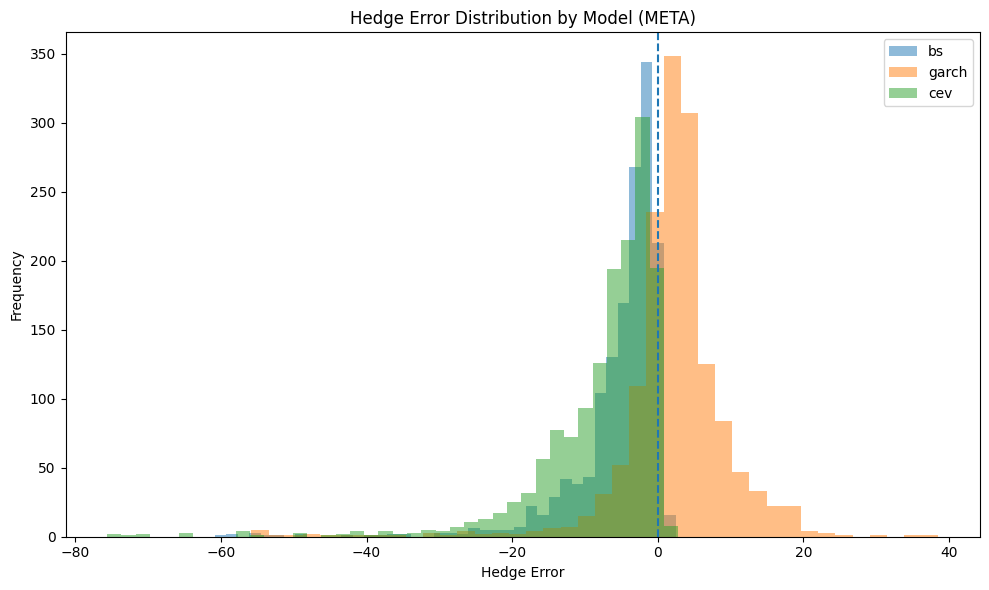

In [65]:
plot_hedge_error_histogram(meta_study, ticker="META",bins=40)

In [104]:
def plot_hedge_error_boxplot(results, ticker=None):

    "Draw boxplots of hedge errors for BS, GARCH, and CEV."

    models = ["bs", "garch", "cev"]
    data = [results[results["model"] == model]["hedge_error"].dropna().values for model in models]

    plt.figure(figsize=(8, 6))
    plt.boxplot(data, labels=models)
    plt.axhline(0.0, linestyle="--")
    plt.ylabel("Hedge Error")
    title = "Boxplot of Hedge Errors by Model"
    if ticker is not None:
        title += f" ({ticker})"
    plt.title(title)
    plt.tight_layout()
    plt.savefig("hedge_error_boxplot.pdf")
    plt.show()

In [69]:
from google.colab import files
files.download("hedge_error_boxplot.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_2638/3046437185.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=models)


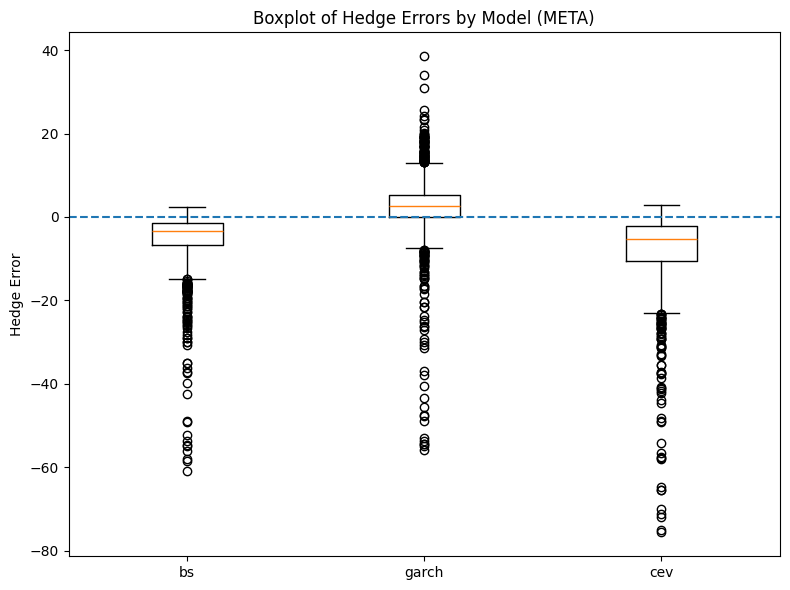

In [68]:
plot_hedge_error_boxplot(meta_study, ticker='META')

In [105]:
def plot_summary_bars(summary, ticker=None):

    "Plot MAE, RMSE, and standard deviation of hedge error by model."

    summary = summary.copy().set_index("model").loc[["bs", "garch", "cev"]]

    metrics = ["mae", "rmse", "std_error"]
    titles = ["Mean Absolute Error", "RMSE", "Std. Dev. of Hedge Error"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, metric, title in zip(axes, metrics, titles):
        ax.bar(summary.index, summary[metric])
        ax.set_title(title)
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)

    main_title = "Model Comparison Summary Statistics"
    if ticker is not None:
        main_title += f" ({ticker})"
    fig.suptitle(main_title, fontsize=14)
    plt.tight_layout()
    plt.savefig("summary_bars.pdf")
    plt.show()

In [76]:
from google.colab import files
files.download("summary_bars.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

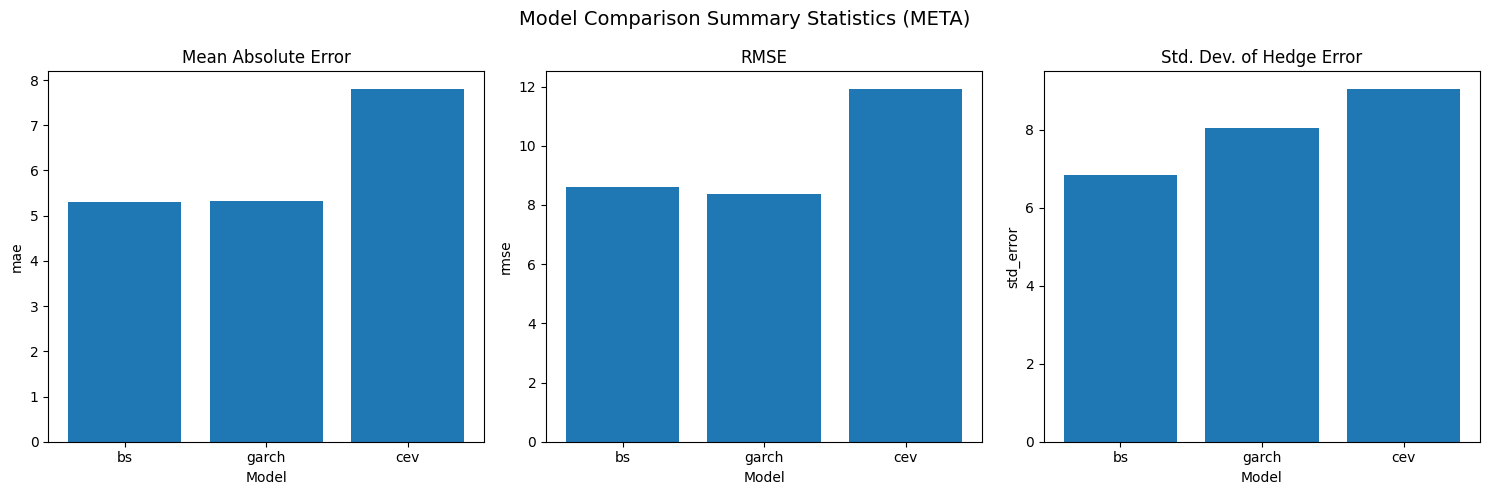

In [71]:
plot_summary_bars(meta_summary, ticker='META')

In [106]:
def plot_cumulative_hedge_error(results, ticker=None):

    "Plot cumulative hedge error over rolling start dates."

    models = ["bs", "garch", "cev"]

    plt.figure(figsize=(10, 6))

    for model in models:
        sub = results[results["model"] == model].sort_values("start_date").copy()
        sub["cum_hedge_error"] = sub["hedge_error"].cumsum()
        plt.plot(sub["start_date"], sub["cum_hedge_error"], label=model)

    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Start Date")
    plt.ylabel("Cumulative Hedge Error")
    title = "Cumulative Hedge Error Over Time"
    if ticker is not None:
        title += f" ({ticker})"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig("cum_hedge_error.pdf")
    plt.show()

In [75]:
from google.colab import files
files.download("cum_hedge_error.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

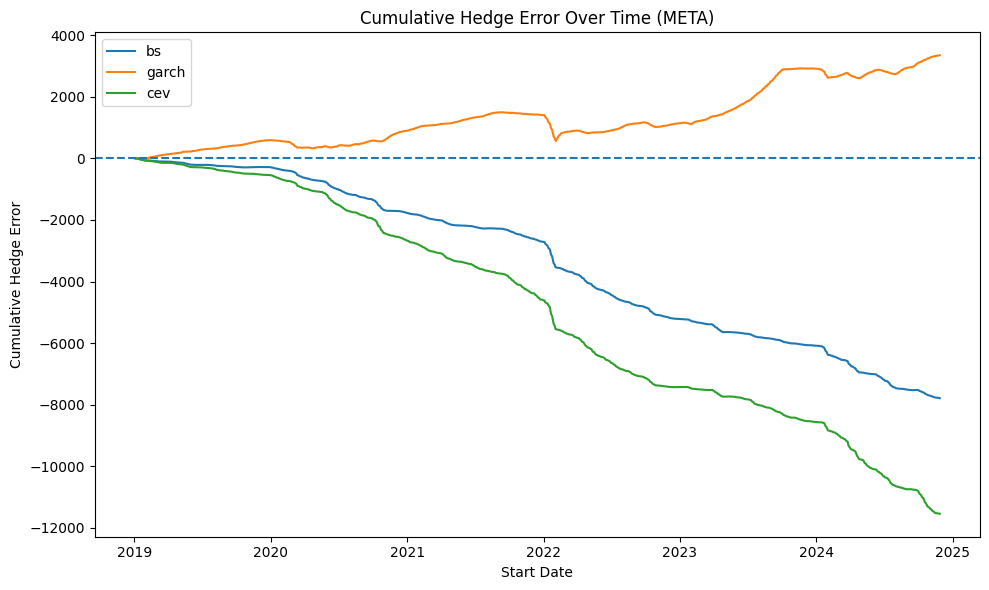

In [74]:
plot_cumulative_hedge_error(meta_study, ticker='META')

In [109]:
def screen_cev_candidates(stock_data, tickers, min_obs=200):

    "Screen the tickers list to identify where CEV is likely to outperform."






    results = []

    for ticker in tickers:
        try:
            S = stock_data['S'][ticker]

            # ensure clean series
            if isinstance(S, pd.DataFrame):
                S = S.iloc[:, 0]

            S = pd.Series(S).dropna().astype(float)

            if len(S) < min_obs:
                continue

            # log returns
            logret = np.log(S / S.shift(1)).dropna()

            # CEV beta regression
            dS = np.diff(S.values)
            dt = 1 / 252

            x = np.log(S.values[:-1] + 1e-12)
            y = np.log((dS**2) / dt + 1e-18)

            slope, intercept, r_val, _, _ = linregress(x, y)

            beta = slope / 2.0
            r2 = r_val**2

            # correlation effect
            if len(logret) > 10:
                lev_corr = np.corrcoef(logret[:-1], logret[1:]**2)[0,1]
            else:
                lev_corr = np.nan

            # downside vs upside variance
            downside = logret[logret < 0]
            upside = logret[logret > 0]

            if len(downside) > 5 and len(upside) > 5:
                downside_var = np.var(downside)
                upside_var = np.var(upside)
                var_ratio = downside_var / (upside_var + 1e-12)
            else:
                var_ratio = np.nan

            # skewness
            skew = logret.skew()

            #  combine into score
            # lower beta (below 1) is better
            beta_score = max(0, 1 - beta)

            # negative correlation is better
            lev_score = max(0, -lev_corr) if not np.isnan(lev_corr) else 0

            # downside dominance
            var_score = max(0, var_ratio - 1) if not np.isnan(var_ratio) else 0

            # negative skew
            skew_score = max(0, -skew)

            # combine
            score = (
                2.0 * beta_score +
                1.5 * lev_score +
                1.5 * var_score +
                1.0 * skew_score +
                1.0 * r2
            )

            results.append({
                "ticker": ticker,
                "beta": beta,
                "r2": r2,
                "leverage_corr": lev_corr,
                "down_up_var_ratio": var_ratio,
                "skew": skew,
                "cev_score": score
            })

        except Exception as e:
            print(f"Skipping {ticker}: {e}")
            continue

    df = pd.DataFrame(results)

    return df.sort_values("cev_score", ascending=False).reset_index(drop=True)

In [108]:
screen_cev_candidates(stock_data, tickers, min_obs=200)

,ticker,beta,r2,leverage_corr,down_up_var_ratio,skew,cev_score
0,USB,-0.856243,0.004020,-0.119774,1.172440,-0.208105,4.362931
1,KO,0.098906,0.000062,-0.104509,1.584113,-0.926650,3.761833
2,EOG,0.310535,0.006171,-0.137387,1.352856,-1.450675,3.571142
3,CVS,0.266826,0.000927,-0.021692,1.621861,-0.971527,3.404131
4,ABBV,0.759665,0.028844,-0.005613,1.870067,-1.410970,3.234004
5,SLB,0.152331,0.000977,-0.097602,1.283142,-0.814777,3.082207
6,VTI,0.479720,0.004610,-0.077265,1.635253,-0.812874,2.926821
7,DIA,0.533768,0.003611,-0.051009,1.598729,-0.989735,2.900418
8,META,0.665562,0.027189,-0.002899,1.517655,-1.339023,2.815919
9,CVX,0.542420,0.014790,-0.024881,1.407209,-1.055924,2.634010
